In [1]:
pip install xgboost pandas scikit-learn numpy


In [2]:
import pandas as pd
path = "/content/HI-Small_Trans.csv"
df = pd.read_csv(path)      # This line loads the data into df
print(df.head())
print(df["Is Laundering"].value_counts())


          Timestamp  From Bank    Account  To Bank  Account.1  \
0  2022/09/01 00:20         10  8000EBD30       10  8000EBD30   
1  2022/09/01 00:20       3208  8000F4580        1  8000F5340   
2  2022/09/01 00:00       3209  8000F4670     3209  8000F4670   
3  2022/09/01 00:02         12  8000F5030       12  8000F5030   
4  2022/09/01 00:06         10  8000F5200       10  8000F5200   

   Amount Received Receiving Currency  Amount Paid Payment Currency  \
0          3697.34          US Dollar      3697.34        US Dollar   
1             0.01          US Dollar         0.01        US Dollar   
2         14675.57          US Dollar     14675.57        US Dollar   
3          2806.97          US Dollar      2806.97        US Dollar   
4         36682.97          US Dollar     36682.97        US Dollar   

  Payment Format  Is Laundering  
0   Reinvestment            0.0  
1         Cheque            0.0  
2   Reinvestment            0.0  
3   Reinvestment            0.0  
4   Reinvest

In [3]:
print("Columns in dataset:", df.columns.tolist())
df.head()


Columns in dataset: ['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0.0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0.0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0.0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0.0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0.0


In [4]:
df["Is Laundering"] = df["Is Laundering"].fillna(0)


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
df_encoded = df.copy()
for col in ['From Bank', 'Account', 'To Bank', 'Account.1',
            'Receiving Currency', 'Payment Currency', 'Payment Format']:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

X = df_encoded.drop(columns=["Is Laundering", "Timestamp"])
y = df_encoded["Is Laundering"]

# Global test set (for evaluation)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [6]:
print("Non-numeric columns:", X.select_dtypes(exclude=['number']).columns.tolist())


Non-numeric columns: []


In [ ]:
!pip install imblearn

In [7]:
# --- Data Balancing (SMOTE) + Label Privacy ---

from imblearn.over_sampling import SMOTE
import numpy as np

# Separate features (X) and label (y)
X = df.drop('Is Laundering', axis=1)
y = df['Is Laundering']

# Keep only numeric columns for SMOTE
X_numeric = X.select_dtypes(include=['number']).copy()

# Fill missing values (NaN) with 0 to avoid SMOTE errors
X_numeric = X_numeric.fillna(0)

# Apply SMOTE for oversampling minority class
sm = SMOTE(random_state=42)
X_res_num, y_res = sm.fit_resample(X_numeric, y)

print(" Class distribution before SMOTE:\n", y.value_counts())
print("\n Class distribution after SMOTE:\n", y_res.value_counts())

# Add small random noise to labels (label privacy)
noise_rate = 0.02  # 2% of labels flipped
y_noisy = y_res.copy()

n_flip = int(noise_rate * len(y_noisy))
flip_indices = np.random.choice(len(y_noisy), n_flip, replace=False)
y_noisy.iloc[flip_indices] = 1 - y_noisy.iloc[flip_indices]  # flip 0 <-> 1

# Replace labels with noisy version
y_res = y_noisy

# Combine resampled data and labels into a new DataFrame
df = pd.concat([X_res_num, y_res], axis=1)

print("\n Final dataset shape after SMOTE and label privacy:", df.shape)
print(" Updated label distribution:\n", df['Is Laundering'].value_counts())


 Class distribution before SMOTE:
 Is Laundering
0.0    928845
1.0       536
Name: count, dtype: int64

 Class distribution after SMOTE:
 Is Laundering
0.0    928845
1.0    928845
Name: count, dtype: int64

 Final dataset shape after SMOTE and label privacy: (1857690, 5)
 Updated label distribution:
 Is Laundering
1.0    928886
0.0    928804
Name: count, dtype: int64


In [8]:
import numpy as np

NUM_CLIENTS = 3
client_data = np.array_split(X_train, NUM_CLIENTS)
client_labels = np.array_split(y_train, NUM_CLIENTS)

#  Add inside each client’s local data preparation
import numpy as np

# Add small random noise to labels for privacy
noise_rate = 0.02  # 2% of labels will be randomly flipped
y_noisy = y_res.copy()

n_flip = int(noise_rate * len(y_noisy))
flip_indices = np.random.choice(len(y_noisy), n_flip, replace=False)
y_noisy.iloc[flip_indices] = 1 - y_noisy.iloc[flip_indices]  # flip 0 <-> 1

# Replace labels with noisy version
y_res = y_noisy



/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


In [9]:

print("Train samples:", len(X_train))
print("Test samples :", len(X_test))
print(f"Train ratio: {len(X_train) / (len(X_train) + len(X_test)):.2%}")
print(f"Test ratio : {len(X_test) / (len(X_train) + len(X_test)):.2%}")

print("\n--- Client-wise distribution ---")
for i in range(NUM_CLIENTS):
    count = len(client_data[i])
    ratio = count / len(X_train)
    print(f"Client {i+1}: {count} samples ({ratio:.2%} of training data)")


Train samples: 743504
Test samples : 185877
Train ratio: 80.00%
Test ratio : 20.00%

--- Client-wise distribution ---
Client 1: 247835 samples (33.33% of training data)
Client 2: 247835 samples (33.33% of training data)
Client 3: 247834 samples (33.33% of training data)


In [10]:
!pip install xgboost
import xgboost as xgb
from sklearn.metrics import accuracy_score
import numpy as np

NUM_ROUNDS = 3
global_preds = None

for rnd in range(NUM_ROUNDS):
    print(f"\n--- Round {rnd+1} ---")
    client_preds = []

    for cid in range(NUM_CLIENTS):
        # Train local model
        dtrain = xgb.DMatrix(client_data[cid], label=client_labels[cid])
        params = {"objective": "binary:logistic", "eval_metric": "logloss"}
        model = xgb.train(params, dtrain, num_boost_round=20)

        # Predict on shared test set
        dtest = xgb.DMatrix(X_test)
        preds = model.predict(dtest)

        # Differential Privacy: add Gaussian noise
        noise = np.random.normal(0, 0.05, size=preds.shape)  # mean=0, std=0.05
        preds_noisy = np.clip(preds + noise, 0, 1)  # keep in [0,1]

        client_preds.append(preds_noisy)

    # Server aggregates by averaging predictions
    global_preds = np.mean(client_preds, axis=0)

    # Evaluate
    y_pred = (global_preds > 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)
    print(f"Round {rnd+1} Federated DP Accuracy: {acc:.4f}")



--- Round 1 ---
Round 1 Federated DP Accuracy: 0.9995

--- Round 2 ---
Round 2 Federated DP Accuracy: 0.9995

--- Round 3 ---
Round 3 Federated DP Accuracy: 0.9995


In [11]:
y_pred_fed = (global_preds > 0.5).astype(int)


In [12]:
# Centralized model (all data together)
dtrain_full = xgb.DMatrix(X_train, label=y_train)
central_model = xgb.train(params, dtrain_full, num_boost_round=50)
central_preds = central_model.predict(xgb.DMatrix(X_test))
central_acc = accuracy_score(y_test, (central_preds > 0.5).astype(int))
print(f"\nCentralized Accuracy: {central_acc:.4f}")

# Incremental learning (simulate training on chunks sequentially)
incremental_model = None
for cid in range(NUM_CLIENTS):
    dtrain = xgb.DMatrix(client_data[cid], label=client_labels[cid])
    if incremental_model is None:
        incremental_model = xgb.train(params, dtrain, num_boost_round=20)
    else:
        incremental_model = xgb.train(
            params, dtrain, num_boost_round=20, xgb_model=incremental_model
        )

inc_preds = incremental_model.predict(xgb.DMatrix(X_test))
inc_acc = accuracy_score(y_test, (inc_preds > 0.5).astype(int))
print(f"Incremental Accuracy: {inc_acc:.4f}")



Centralized Accuracy: 0.9995
Incremental Accuracy: 0.9995


In [45]:
# Identify suspicious transactions (label == 1)
suspicious_indices = np.where(y_pred_fed == 1)[0]  # Use Federated DP predictions

if len(suspicious_indices) > 0:
    print("\n⚠️ ALERT: Suspicious Transactions Detected!")
    for i in suspicious_indices:
        txn_id = X_test.iloc[i]['Transaction_ID'] if 'Transaction_ID' in X_test.columns else i
        print(f"🚨 Suspicious Transaction ID: {txn_id}")
else:
    print("\n✅ No suspicious transactions detected.")



⚠️ ALERT: Suspicious Transactions Detected!
🚨 Suspicious Transaction ID: 1038
🚨 Suspicious Transaction ID: 5468
🚨 Suspicious Transaction ID: 6075
🚨 Suspicious Transaction ID: 6232
🚨 Suspicious Transaction ID: 18105
🚨 Suspicious Transaction ID: 26460
🚨 Suspicious Transaction ID: 60180
🚨 Suspicious Transaction ID: 65400
🚨 Suspicious Transaction ID: 67375
🚨 Suspicious Transaction ID: 69551
🚨 Suspicious Transaction ID: 79024
🚨 Suspicious Transaction ID: 92260
🚨 Suspicious Transaction ID: 92877
🚨 Suspicious Transaction ID: 95550
🚨 Suspicious Transaction ID: 104458
🚨 Suspicious Transaction ID: 108229
🚨 Suspicious Transaction ID: 116462
🚨 Suspicious Transaction ID: 116483
🚨 Suspicious Transaction ID: 129443
🚨 Suspicious Transaction ID: 142715
🚨 Suspicious Transaction ID: 149462
🚨 Suspicious Transaction ID: 157412
🚨 Suspicious Transaction ID: 174319
🚨 Suspicious Transaction ID: 177013
🚨 Suspicious Transaction ID: 180126
🚨 Suspicious Transaction ID: 183774
🚨 Suspicious Transaction ID: 184732


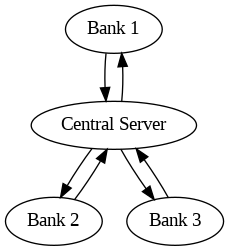

In [15]:
from graphviz import Digraph
from IPython.display import Image

# --- Federated Learning Diagram ---
dot = Digraph(comment='Federated AML System')

# Clients / Banks
dot.node('B1', 'Bank 1')
dot.node('B2', 'Bank 2')
dot.node('B3', 'Bank 3')

# Central Server
dot.node('S', 'Central Server')

# Connections: Clients -> Server
dot.edges([('B1','S'), ('B2','S'), ('B3','S')])

# Connections: Server -> Clients (updated model)
dot.edges([('S','B1'), ('S','B2'), ('S','B3')])

# Render PNG
dot.render('federated_learning_diagram', format='png', cleanup=True)

# Display inline
Image(filename='federated_learning_diagram.png')


/tmp/ipython-input-1001438261.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette="mako")


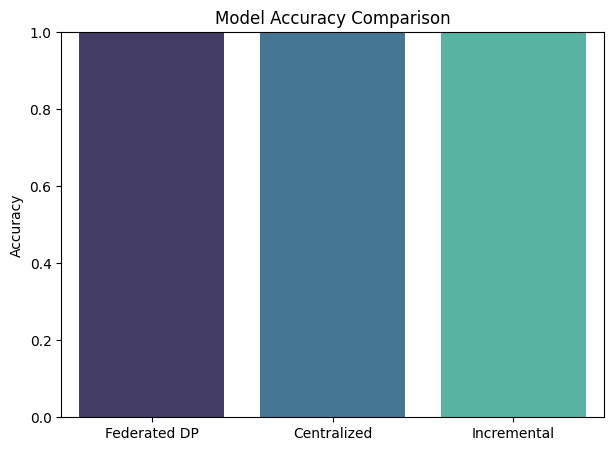

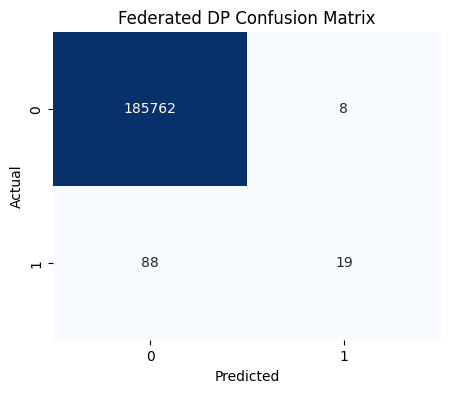

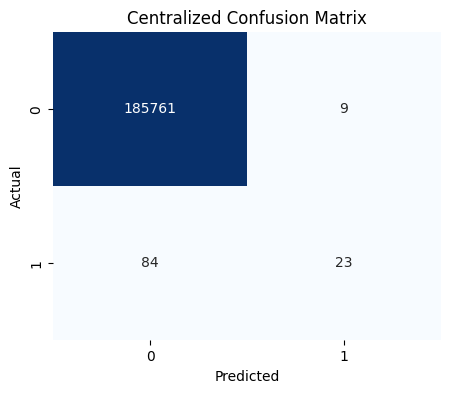

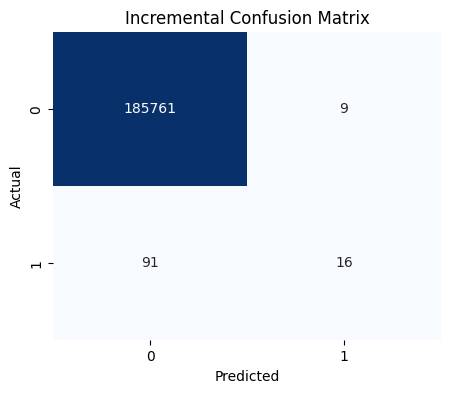

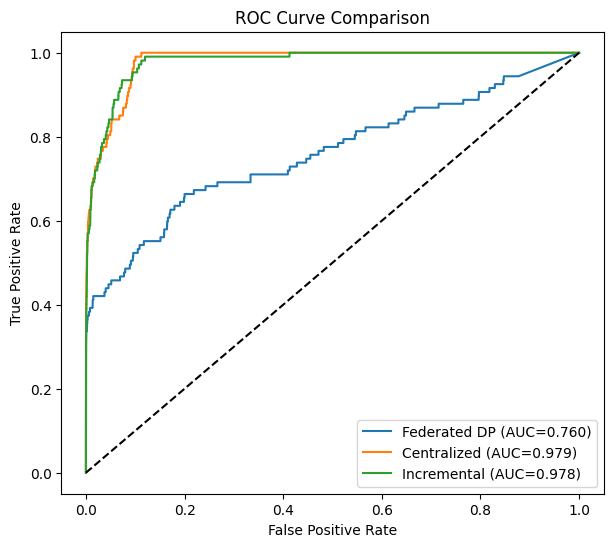


Classification Report (Federated DP):

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    185770
         1.0       0.70      0.18      0.28       107

    accuracy                           1.00    185877
   macro avg       0.85      0.59      0.64    185877
weighted avg       1.00      1.00      1.00    185877


Classification Report (Centralized XGboost):

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    185770
         1.0       0.72      0.21      0.33       107

    accuracy                           1.00    185877
   macro avg       0.86      0.61      0.67    185877
weighted avg       1.00      1.00      1.00    185877


Classification Report (Incremental Learning):

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    185770
         1.0       0.64      0.15      0.24       107

    accuracy                           1.00    

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Accuracy Comparison
models = ["Federated DP", "Centralized", "Incremental"]
accuracies = [acc, central_acc, inc_acc]

plt.figure(figsize=(7,5))
sns.barplot(x=models, y=accuracies, palette="mako")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# Confusion Matrices
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Predictions from each model
y_pred_fed = (global_preds > 0.5).astype(int)
y_pred_central = (central_preds > 0.5).astype(int)
y_pred_inc = (inc_preds > 0.5).astype(int)

# Plot confusion matrices
plot_conf_matrix(y_test, y_pred_fed, "Federated DP Confusion Matrix")
plot_conf_matrix(y_test, y_pred_central, "Centralized Confusion Matrix")
plot_conf_matrix(y_test, y_pred_inc, "Incremental Confusion Matrix")

#ROC Curve Comparison
plt.figure(figsize=(7,6))

# Federated DP ROC
fpr, tpr, _ = roc_curve(y_test, global_preds)
plt.plot(fpr, tpr, label=f"Federated DP (AUC={auc(fpr,tpr):.3f})")

# Centralized ROC
fpr, tpr, _ = roc_curve(y_test, central_preds)
plt.plot(fpr, tpr, label=f"Centralized (AUC={auc(fpr,tpr):.3f})")

# Incremental ROC
fpr, tpr, _ = roc_curve(y_test, inc_preds)
plt.plot(fpr, tpr, label=f"Incremental (AUC={auc(fpr,tpr):.3f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Detailed Classification Reports
print("\nClassification Report (Federated DP):\n")
print(classification_report(y_test, y_pred_fed))

print("\nClassification Report (Centralized XGboost):\n")
print(classification_report(y_test, y_pred_central))

print("\nClassification Report (Incremental Learning):\n")
print(classification_report(y_test, y_pred_inc))


In [50]:
from sklearn.metrics import accuracy_score, classification_report

# Federated DP Metrics
y_pred_fed = (global_preds > 0.5).astype(int)
acc_fed = accuracy_score(y_test, y_pred_fed)
print("Federated DP Accuracy:", round(acc_fed, 4))
print("Federated DP Classification Report:\n")
print(classification_report(y_test, y_pred_fed, digits=2))

#  Centralized XGBoost Metrics
y_pred_central = (central_preds > 0.5).astype(int)
acc_central = accuracy_score(y_test, y_pred_central)
print("\nCentralized XGBoost Accuracy:", round(acc_central, 4))
print("Centralized XGBoost Classification Report:\n")
print(classification_report(y_test, y_pred_central, digits=2))

#Incremental Learning Metrics
y_pred_inc = (inc_preds > 0.5).astype(int)
acc_inc = accuracy_score(y_test, y_pred_inc)
print("\nIncremental Learning Accuracy:", round(acc_inc, 4))
print("Incremental Learning Classification Report:\n")
print(classification_report(y_test, y_pred_inc, digits=2))


Federated DP Accuracy: 0.9995
Federated DP Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    185770
         1.0       0.70      0.18      0.28       107

    accuracy                           1.00    185877
   macro avg       0.85      0.59      0.64    185877
weighted avg       1.00      1.00      1.00    185877


Centralized XGBoost Accuracy: 0.9995
Centralized XGBoost Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    185770
         1.0       0.72      0.21      0.33       107

    accuracy                           1.00    185877
   macro avg       0.86      0.61      0.67    185877
weighted avg       1.00      1.00      1.00    185877


Incremental Learning Accuracy: 0.9995
Incremental Learning Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    185770
    

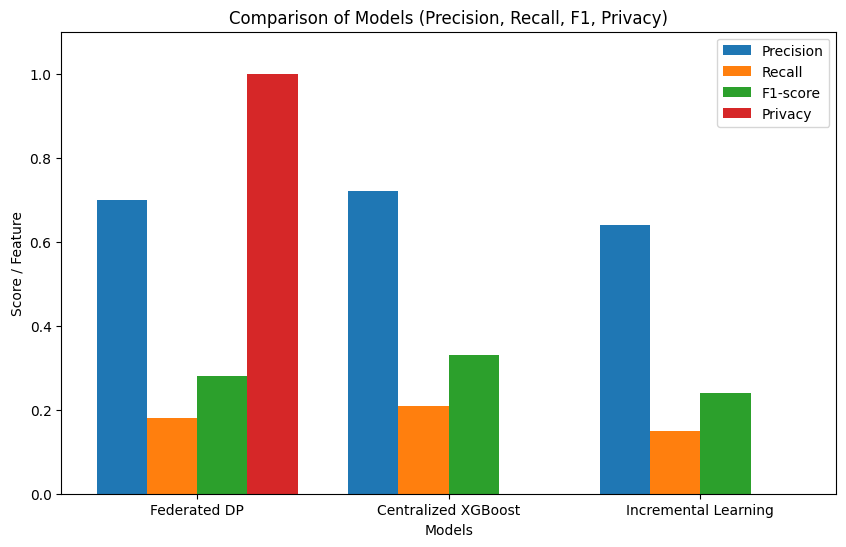

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics for each model
models = ['Federated DP', 'Centralized XGBoost', 'Incremental Learning']
precision = [0.70, 0.72, 0.64]
recall    = [0.18, 0.21, 0.15]
f1_score  = [0.28, 0.33, 0.24]
privacy   = [1, 0, 0]  # 1 = Yes, 0 = No

x = np.arange(len(models))  # model positions
width = 0.2

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - 1.5*width, precision, width, label='Precision')
ax.bar(x - 0.5*width, recall, width, label='Recall')
ax.bar(x + 0.5*width, f1_score, width, label='F1-score')
ax.bar(x + 1.5*width, privacy, width, label='Privacy')

ax.set_xlabel('Models')
ax.set_ylabel('Score / Feature')
ax.set_title('Comparison of Models (Precision, Recall, F1, Privacy)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
plt.ylim(0,1.1)
plt.show()


In [42]:
from graphviz import Digraph

fed_dp = Digraph(comment='Federated Learning with DP Architecture')

# Nodes
fed_dp.node('A', 'Client 1\n(Local Transaction Data)\nPreprocessing + Feature Engineering')
fed_dp.node('B', 'Client 2\n(Local Transaction Data)\nPreprocessing + Feature Engineering')
fed_dp.node('C', 'Client N\n(Local Transaction Data)\nPreprocessing + Feature Engineering')
fed_dp.node('D', 'Differential Privacy Layer\n(Add Noise to Local Model Updates)')
fed_dp.node('E', 'Federated Aggregation Server\n(FedAvg / Model Update Aggregation)')
fed_dp.node('F', 'Global Model\n(Synchronized with Clients)')
fed_dp.node('G', 'Prediction & Suspicious Transaction Alert')

# Edges
fed_dp.edge('A', 'D')
fed_dp.edge('B', 'D')
fed_dp.edge('C', 'D')
fed_dp.edge('D', 'E')
fed_dp.edge('E', 'F')
fed_dp.edge('F', 'G')

# Render diagram
fed_dp.render('federated_dp_architecture', format='png', cleanup=True)


'federated_dp_architecture.png'

In [39]:
from graphviz import Digraph
from IPython.display import Image

dot = Digraph(comment='Suspicious Transaction Detection Architecture')

# Data flow
dot.node('A', 'Transaction Data\n(CSV/Database)')
dot.node('B', 'Preprocessing\n(Encoding, Scaling)')
dot.node('C', 'Feature Selection / Handling Imbalance')
dot.node('D', 'Model Training\n(Federated DP/ Centralized XGboost /Incremental Learning)')
dot.node('E', 'Prediction')
dot.node('F', 'Suspicious Transaction Alert')

# Edges
dot.edges(['AB', 'BC', 'CD', 'DE', 'EF'])

# Render and display diagram
dot.render('architecture_diagram', format='png', cleanup=True)



'architecture_diagram.png'

In [40]:
# --- Methodology Diagram ---
method = Digraph(comment='Suspicious Transaction Detection Methodology')

# Nodes
method.node('1', 'Data Collection\n(Transaction CSV/Database)')
method.node('2', 'Data Cleaning & Preprocessing\n(Encoding, Scaling)')
method.node('3', 'Feature Engineering & Selection\n(Remove Redundant Features)')
method.node('4', 'Handle Imbalanced Data\n(SMOTE / Oversampling)')
method.node('5', 'Model Training\n(Federated DP, Centralized XGboost,Incremental Learning)')
method.node('6', 'Model Evaluation\n(Accuracy, F1 Score, Confusion Matrix)')
method.node('7', 'Prediction on Test Data')
method.node('8', 'Suspicious Transaction Detection & Alert Generation')

# Edges
method.edges(['12','23','34','45','56','67','78'])

# Render
method.render('methodology_diagram', format='png', cleanup=True)



'methodology_diagram.png'

In [41]:
from google.colab import files

# Download Architecture Diagram
files.download('architecture_diagram.png')

# Download Methodology Diagram
files.download('methodology_diagram.png')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
from graphviz import Digraph

diagram = Digraph(comment='Federated DP vs Centralized Model')

# Federated DP flow
diagram.node('C1', 'Client 1\n(Local Data)')
diagram.node('C2', 'Client 2\n(Local Data)')
diagram.node('C3', 'Client 3\n(Local Data)')
diagram.node('DP', 'Differential Privacy Layer\n(Noise Added)')
diagram.node('AGG', 'Server Aggregation\n(FedDp)')
diagram.node('GM', 'Global Model\n(Prediction & Alert)')

diagram.edges([('C1','DP'), ('C2','DP'), ('C3','DP'), ('DP','AGG'), ('AGG','GM')])

# Centralized flow
diagram.node('CENT', 'Centralized Data\n(All Clients)')
diagram.node('CEN_MODEL', 'Centralized XGBoost Model\n(Prediction & Alert)')

diagram.edge('CENT', 'CEN_MODEL', label='Data Risk')

# Render
diagram.render('federated_vs_centralized', format='png', cleanup=True)


'federated_vs_centralized.png'